# **Final Demo Notebook**

## **Data Preparation**

### **Load the dataset**

In [33]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../Datasets/dataset.csv')

### **Clean the dataset (Drop uneeded columns and extreme outliers)**

Drop columns that are not relevant to a prediction problem (i.e. Track ID has no correlation to genre)

In [34]:
cols_to_drop = ["Unnamed: 0", "track_id", "mode"]
cleaned_df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])
cleaned_df = cleaned_df.dropna()

Remove numeric outliers (1.5 * IQR) as they may affect predictions more heavily than they should

In [35]:
numeric_cols = cleaned_df.select_dtypes(include=[np.number]).columns

Q1 = cleaned_df[numeric_cols].quantile(0.25)
Q3 = cleaned_df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

df_clean = cleaned_df[~((cleaned_df[numeric_cols] < (Q1 - 1.5 * IQR)) |
                (cleaned_df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]
df_clean.reset_index(drop=True, inplace=True)

Remove duplicate songs

In [36]:
if 'track_name' in df_clean.columns and 'artists' in df_clean.columns:
    df_clean = df_clean.drop_duplicates(subset=['track_name', 'artists']).reset_index(drop=True)

Change explicit from boolean to an integer

In [37]:
if 'explicit' in df_clean.columns:
    df_clean["explicit_int"] = df_clean["explicit"].astype(int)

First bin tempos into slow, medium, and fast. Then, one-hot encode them into numeric features.

In [38]:
# if 'tempo' in df_clean.columns:
#     tempo_bins = pd.cut(
#         df_clean["tempo"],
#         bins=[0, 90, 130, df_clean["tempo"].max()],
#         labels=["slow", "medium", "fast"],
#         include_lowest=True,
#     )
#     tempo_dummies = pd.get_dummies(tempo_bins, prefix="tempo")
#     for col in ["tempo_slow", "tempo_medium", "tempo_fast"]:
#         if col not in tempo_dummies.columns:
#             tempo_dummies[col] = 0
#     df_clean[["tempo_slow", "tempo_medium", "tempo_fast"]] = tempo_dummies[[
#         "tempo_slow", "tempo_medium", "tempo_fast",
# ]]

### **Perform train test split**

Create train test split datasets

In [39]:
train_df, test_df = train_test_split(df_clean, test_size=0.2, random_state=42)
train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

Define engineered and untouched feature columns

In [40]:
full_feature_cols = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "duration_ms", "popularity", "key", "time_signature",
]

selected_feature_cols = [
    "danceability", "energy", "loudness", "acousticness",
    "instrumentalness", "valence", "speechiness", "liveness",
    "tempo", "duration_ms",
    "popularity",
]

Scale numeric features to prevent larger values from dominating model and be KNN ready

In [41]:
genre_cols = [c for c in df_clean.columns if 'genre' in c.lower()]
target_genre_col = genre_cols[0]
print(f"Using genre column as target: {target_genre_col}")

def prepare_scaled_matrices(df_train, df_eval, feature_cols):
    df_train_feat = df_train.dropna(subset=feature_cols).reset_index(drop=True)
    df_eval_feat = df_eval.dropna(subset=feature_cols).reset_index(drop=True)

    X_train = df_train_feat[feature_cols].values
    X_eval = df_eval_feat[feature_cols].values

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_eval_scaled = scaler.transform(X_eval)

    return X_train_scaled, X_eval_scaled

Using genre column as target: track_genre


## **Models**

### **Baseline Model (Random)**

In [42]:
def evaluate_baseline_genre(df_train, df_eval, genre_col):
    y_train = df_train[genre_col].astype('category')
    y_eval = df_eval[genre_col].astype('category')

    majority_genre = y_train.value_counts().idxmax()

    train_pred = [majority_genre] * len(y_train)
    eval_pred = [majority_genre] * len(y_eval)

    train_error = float(np.mean(np.array(train_pred) != np.array(y_train)))
    eval_error = float(np.mean(np.array(eval_pred) != np.array(y_eval)))

    return majority_genre, train_error, eval_error

### **KNN Model**

In [43]:
def train_knn_genre(df_train, df_eval, feature_cols, genre_col, k=10):
    X_train_scaled, X_eval_scaled = prepare_scaled_matrices(df_train, df_eval, feature_cols)
    y_train = df_train[genre_col].astype('category')
    y_eval = df_eval[genre_col].astype('category')
    knn_clf = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn_clf.fit(X_train_scaled, y_train)
    train_pred = knn_clf.predict(X_train_scaled)
    eval_pred = knn_clf.predict(X_eval_scaled)
    train_acc = float(np.mean(train_pred == y_train))
    eval_acc = float(np.mean(eval_pred == y_eval))
    return knn_clf, train_acc, eval_acc

### **Logistic Regression Model**

In [52]:
def train_logistic_regression(df_train, df_eval, feature_cols, genre_col):
    X_train_scaled, X_eval_scaled = prepare_scaled_matrices(df_train, df_eval, feature_cols)
    y_train = df_train[genre_col].astype("category")
    y_eval = df_eval[genre_col].astype("category")
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_scaled, y_train)
    train_pred = model.predict(X_train_scaled)
    eval_pred = model.predict(X_eval_scaled)
    train_acc = float(np.mean(train_pred == y_train))
    eval_acc = float(np.mean(eval_pred == y_eval))
    return model, train_acc, eval_acc

### **Decision Tree Model**

In [45]:
def train_decision_tree(df_train, df_eval, feature_cols, genre_col, max_depth=20, random_state=42):
    X_train_scaled, X_eval_scaled = prepare_scaled_matrices(df_train, df_eval, feature_cols)
    y_train = df_train[genre_col].astype("category")
    y_eval = df_eval[genre_col].astype("category")
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)
    model.fit(X_train_scaled, y_train)
    train_pred = model.predict(X_train_scaled)
    eval_pred = model.predict(X_eval_scaled)
    train_acc = float(np.mean(train_pred == y_train))
    eval_acc = float(np.mean(eval_pred == y_eval))
    return model, train_acc, eval_acc

### **Random Forest Model**

In [46]:
def train_random_forest(df_train, df_eval, feature_cols, genre_col, n_estimators=200, max_depth=None, random_state=42):
    X_train_scaled, X_eval_scaled = prepare_scaled_matrices(df_train, df_eval, feature_cols)
    y_train = df_train[genre_col].astype("category")
    y_eval = df_eval[genre_col].astype("category")
    model = RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth, random_state=random_state, n_jobs=-1
    )
    model.fit(X_train_scaled, y_train)
    train_pred = model.predict(X_train_scaled)
    eval_pred = model.predict(X_eval_scaled)
    train_acc = float(np.mean(train_pred == y_train))
    eval_acc = float(np.mean(eval_pred == y_eval))
    return model, train_acc, eval_acc

## **Model Performance**

### **Tuning Value of K**

Try and retrain model with different values of k to find maximum accuracy

In [47]:
ks_to_try = [3, 5, 10, 20, 50, 100]
results_by_k = {}

baseline_genre, baseline_train_error, baseline_test_error = evaluate_baseline_genre(
    train_df, test_df, target_genre_col
)
baseline_train_accuracy = 1.0 - baseline_train_error
baseline_test_accuracy = 1.0 - baseline_test_error
print(
    f"Baseline (most common genre = '{baseline_genre}') -> "
    f"train accuracy: {baseline_train_accuracy:.4f}, "
    f"test accuracy: {baseline_test_accuracy:.4f}\n"
 )

for k in ks_to_try:
    knn_clf, train_accuracy, eval_accuracy = train_knn_genre(
        train_df, test_df, selected_feature_cols, target_genre_col, k=k
    )
    results_by_k[k] = {
        "train_accuracy": train_accuracy,
        "test_accuracy": eval_accuracy,
    }
    print(
        f"k = {k}: KNN train accuracy = {train_accuracy:.4f}, "
        f"test accuracy: {eval_accuracy:.4f}"
    )

best_k = max(results_by_k, key=lambda kk: results_by_k[kk]["test_accuracy"])
knn_selected_train_acc = results_by_k[best_k]["train_accuracy"]
knn_selected_test_acc = results_by_k[best_k]["test_accuracy"]
print(
    f"\nBest k based on highest test accuracy (selected features): k = {best_k}"
)

Baseline (most common genre = 'salsa') -> train accuracy: 0.0192, test accuracy: 0.0200

k = 3: KNN train accuracy = 0.4739, test accuracy: 0.1618
k = 5: KNN train accuracy = 0.4012, test accuracy: 0.1791
k = 10: KNN train accuracy = 0.3464, test accuracy: 0.1973
k = 20: KNN train accuracy = 0.3006, test accuracy: 0.2096
k = 50: KNN train accuracy = 0.2589, test accuracy: 0.2146
k = 100: KNN train accuracy = 0.2371, test accuracy: 0.2096

Best k based on highest test accuracy (selected features): k = 50


The below graph shows the test accuracy as K increases

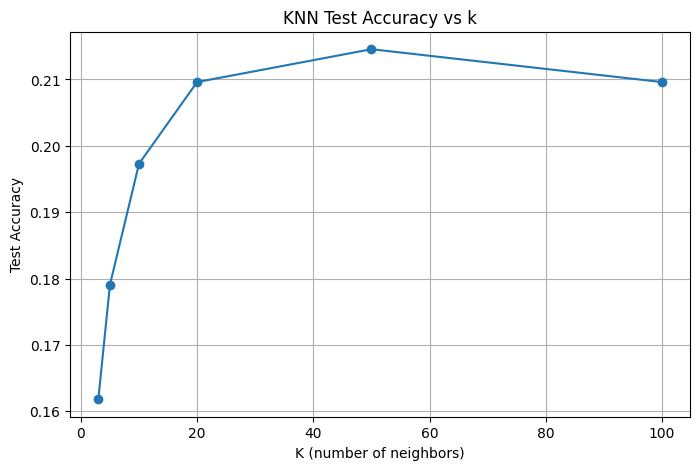

In [48]:
k_values = sorted(results_by_k.keys())
test_accuracies = [results_by_k[k]["test_accuracy"] for k in k_values]

plt.figure(figsize=(8, 5))
plt.plot(k_values, test_accuracies, marker="o")
plt.title("KNN Test Accuracy vs k")
plt.xlabel("K (number of neighbors)")
plt.ylabel("Test Accuracy")
plt.grid(True)
plt.show()

### **Logistic Regressor**

In [53]:
log_reg, train_acc_lr, test_acc_lr = train_logistic_regression(
    train_df, test_df, selected_feature_cols, target_genre_col
)

print("--- Logistic Regressor ---")
print(f"Training accuracy: {train_acc_lr:.4f}")
print(f"Test accuracy: {test_acc_lr:.4f}")

--- Logistic Regressor ---
Training accuracy: 0.2000
Test accuracy: 0.1917


### **Decision Tree Model**

In [50]:
dt_clf, train_acc_dt, test_acc_dt = train_decision_tree(
    train_df, test_df, selected_feature_cols, target_genre_col, max_depth=20, random_state=42
)

print("--- Decision Tree ---")
print(f"Training accuracy: {train_acc_dt:.4f}")
print(f"Test accuracy: {test_acc_dt:.4f}")

--- Decision Tree ---
Training accuracy: 0.9079
Test accuracy: 0.1753


### **Random Forest Model**

In [51]:
rf_clf, train_acc_rf, test_acc_rf = train_random_forest(
    train_df, test_df, selected_feature_cols, target_genre_col, n_estimators=200, max_depth=None, random_state=42
)

print("--- Random Forest ---")
print(f"Training accuracy: {train_acc_rf:.4f}")
print(f"Test accuracy: {test_acc_rf:.4f}")

--- Random Forest ---
Training accuracy: 1.0000
Test accuracy: 0.3186


### **Running All Models Using All Features**

In [54]:
print("--- Full-feature models (no engineered features) ---")

knn_full, train_full_knn_acc, test_full_knn_acc = train_knn_genre(
    train_df, test_df, full_feature_cols, target_genre_col, k=best_k
)
print(f"KNN (full features) test accuracy: {test_full_knn_acc:.4f}")

log_full, train_full_lr_acc, test_full_lr_acc = train_logistic_regression(
    train_df, test_df, full_feature_cols, target_genre_col
)
print(f"Logistic Regression (full features) test accuracy: {test_full_lr_acc:.4f}")

dt_full, train_full_dt_acc, test_full_dt_acc = train_decision_tree(
    train_df, test_df, full_feature_cols, target_genre_col, max_depth=20, random_state=42
)
print(f"Decision Tree (full features) test accuracy: {test_full_dt_acc:.4f}")

rf_full, train_full_rf_acc, test_full_rf_acc = train_random_forest(
    train_df, test_df, full_feature_cols, target_genre_col, n_estimators=200, max_depth=None, random_state=42
)
print(f"Random Forest (full features) test accuracy: {test_full_rf_acc:.4f}")

--- Full-feature models (no engineered features) ---
KNN (full features) test accuracy: 0.1986
Logistic Regression (full features) test accuracy: 0.1928
Decision Tree (full features) test accuracy: 0.1755
Random Forest (full features) test accuracy: 0.3139


## **Model Comparisons**

### **Comparison of Models on Engineered Features**

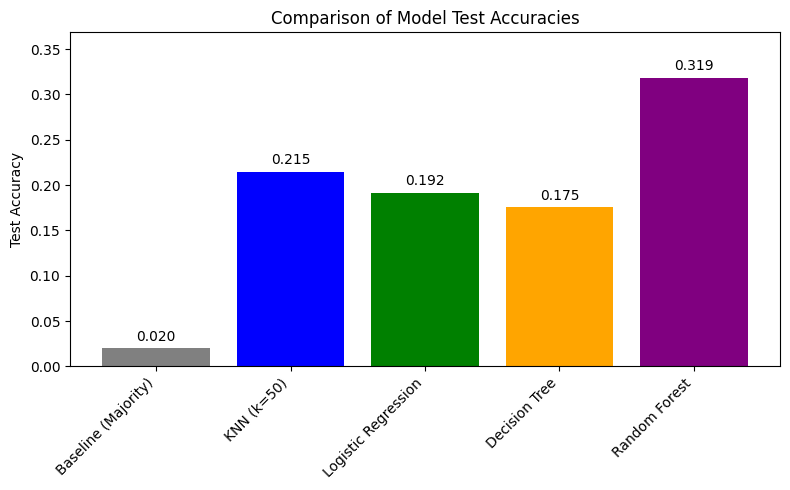

In [55]:
model_names = [
    "Baseline (Majority)",
    f"KNN (k={best_k})",
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
]

accuracies = [
    baseline_test_accuracy,
    results_by_k[best_k]["test_accuracy"],
    test_acc_lr,
    test_acc_dt,
    test_acc_rf,
]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, accuracies, color=["gray", "blue", "green", "orange", "purple"])
plt.ylim(0, max(accuracies) + 0.05)
plt.ylabel("Test Accuracy")
plt.title("Comparison of Model Test Accuracies")
plt.xticks(rotation=45, ha="right")

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f"{acc:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

### **Five-Fold Cross-Validation Comparison**

In [57]:
X_train_cv, _ = prepare_scaled_matrices(train_df, train_df, selected_feature_cols)
y_train_cv = train_df[target_genre_col].astype("category")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_accuracy(model, name):
    scores = cross_val_score(model, X_train_cv, y_train_cv, cv=cv, scoring="accuracy")
    print(f"{name}: mean CV accuracy = {scores.mean():.4f} (+/- {scores.std():.4f})")

print("--- 5-fold Cross-Validation ---")

majority_genre = y_train_cv.value_counts().idxmax()
baseline_acc = float(np.mean(y_train_cv == majority_genre))
print(f"Baseline (always '{majority_genre}'): accuracy = {baseline_acc:.4f}")

knn_cv = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")
cv_accuracy(knn_cv, f"KNN (k={best_k})")

log_reg_cv = LogisticRegression(max_iter=1000)
cv_accuracy(log_reg_cv, "Logistic Regression")

dt_cv = DecisionTreeClassifier(max_depth=20, random_state=42)
cv_accuracy(dt_cv, "Decision Tree")

rf_cv = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
cv_accuracy(rf_cv, "Random Forest")

--- 5-fold Cross-Validation ---
Baseline (always 'salsa'): accuracy = 0.0192
KNN (k=50): mean CV accuracy = 0.2106 (+/- 0.0050)
Logistic Regression: mean CV accuracy = 0.1936 (+/- 0.0049)
Decision Tree: mean CV accuracy = 0.1730 (+/- 0.0047)
Random Forest: mean CV accuracy = 0.3126 (+/- 0.0058)


### **Effect of Feature Engineering on Accuracy**

,Model,Full features (no engineered),Selected features (with engineering),Improvement
0,KNN,0.198624,0.214553,0.015929
1,Logistic Regression,0.192832,0.191746,-0.001086
2,Decision Tree,0.175456,0.175335,-0.000121
3,Random Forest,0.313865,0.318571,0.004706


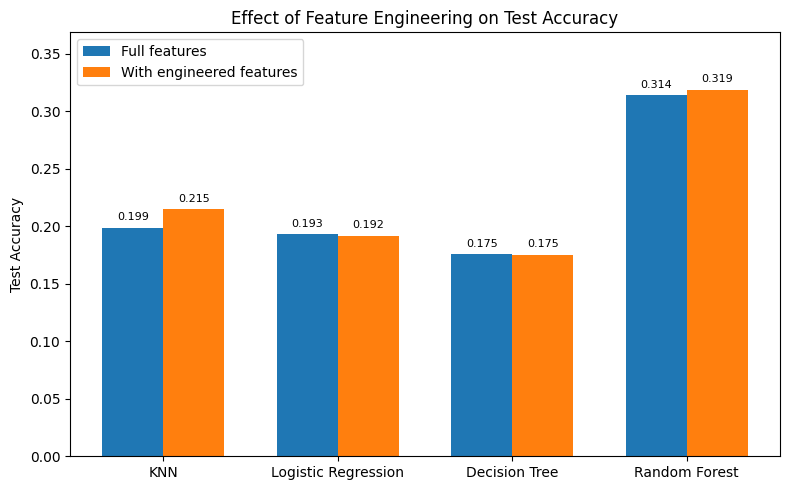

In [58]:
models = ["KNN", "Logistic Regression", "Decision Tree", "Random Forest"]

full_accs = [
    test_full_knn_acc,
    test_full_lr_acc,
    test_full_dt_acc,
    test_full_rf_acc,
 ]
sel_accs = [
    results_by_k[best_k]["test_accuracy"],
    test_acc_lr,
    test_acc_dt,
    test_acc_rf,
 ]

comparison_df = pd.DataFrame({
    "Model": models,
    "Full features (no engineered)": full_accs,
    "Selected features (with engineering)": sel_accs,
})
comparison_df["Improvement"] = comparison_df["Selected features (with engineering)"] - comparison_df["Full features (no engineered)"]
display(comparison_df)

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, full_accs, width, label="Full features")
plt.bar(x + width/2, sel_accs, width, label="With engineered features")
plt.xticks(x, models)
plt.ylabel("Test Accuracy")
plt.title("Effect of Feature Engineering on Test Accuracy")
plt.legend()
plt.ylim(0, max(max(full_accs), max(sel_accs)) + 0.05)

for i, (fa, sa) in enumerate(zip(full_accs, sel_accs)):
    plt.text(i - width/2, fa + 0.005, f"{fa:.3f}", ha="center", va="bottom", fontsize=8)
    plt.text(i + width/2, sa + 0.005, f"{sa:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## **Feature Importances**
Our random forest was used as it was our most accurate classifier

,importance
popularity,0.120220
duration_ms,0.100603
acousticness,0.097689
valence,0.092777
danceability,0.092572
tempo,0.091543
loudness,0.089418
energy,0.088552
speechiness,0.086799
liveness,0.078178


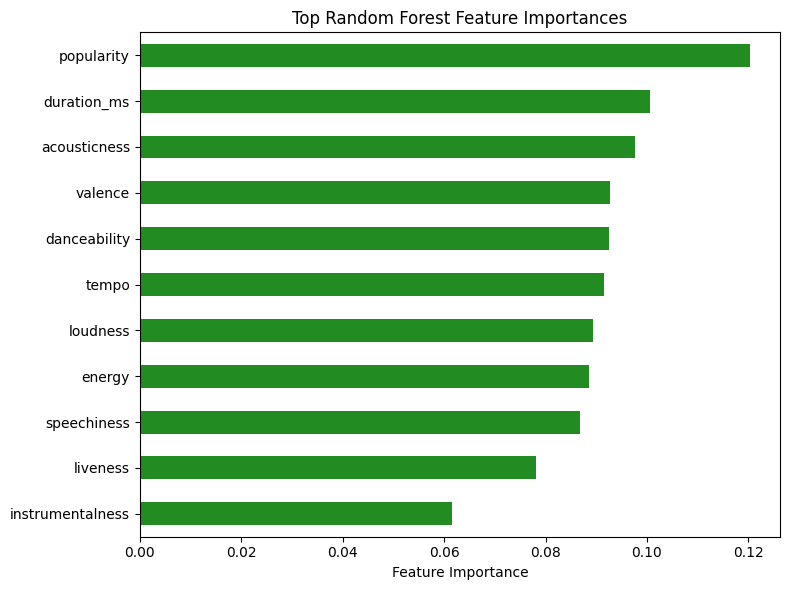

In [59]:
rf_importances = pd.Series(rf_clf.feature_importances_, index=selected_feature_cols)
rf_importances = rf_importances.sort_values(ascending=False)
display(rf_importances.to_frame("importance").head(20))

top_n = 15
plt.figure(figsize=(8, 6))
rf_importances.head(top_n).plot(kind="barh", color="forestgreen")
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Top Random Forest Feature Importances")
plt.tight_layout()
plt.show()